In [1]:
import sys
print(sys.executable)

c:\Users\ICE Laptop\OneDrive\文档\Tugas Kuliah\AI12\venv\Scripts\python.exe


In [2]:
import os
import sys
import tensorflow as tf
from tensorflow.keras.applications import Xception
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import numpy as np
import matplotlib.pyplot as plt

# Ensure UTF-8 output on Windows to avoid UnicodeEncodeError for paths with non-ASCII characters.
if hasattr(sys.stdout, "reconfigure"):
    sys.stdout.reconfigure(encoding="utf-8")
    sys.stderr.reconfigure(encoding="utf-8")
os.environ["PYTHONIOENCODING"] = "utf-8"

print(f"TensorFlow Version: {tf.__version__}")

TensorFlow Version: 2.21.0


In [3]:
# Tentukan path direktori dataset Anda
TRAIN_DIR = 'data/train'
TEST_DIR = 'data/test'

# Augmentasi data latih (Train)
train_datagen = ImageDataGenerator(
    rescale=1./255, 
    rotation_range=20, 
    zoom_range=0.2, 
    horizontal_flip=True
)

# Hanya rescale untuk data uji (Test/Validation)
test_datagen = ImageDataGenerator(rescale=1./255)

# Load dataset
train_generator = train_datagen.flow_from_directory(
    TRAIN_DIR, 
    target_size=(299, 299), # Ukuran input default Xception
    batch_size=32, 
    class_mode='sparse'
)

test_generator = test_datagen.flow_from_directory(
    TEST_DIR, 
    target_size=(299, 299), 
    batch_size=32, 
    class_mode='sparse'
)

# Mendapatkan jumlah kelas dan pemetaan namanya
NUM_CLASSES = train_generator.num_classes
CLASS_MAPPING = train_generator.class_indices

print(f"\n[INFO] Jumlah Kategori: {NUM_CLASSES}")
print(f"[INFO] Urutan Kelas: {list(CLASS_MAPPING.keys())}")

Found 557 images belonging to 2 classes.
Found 140 images belonging to 2 classes.

[INFO] Jumlah Kategori: 2
[INFO] Urutan Kelas: ['cats', 'dogs']


In [4]:
# Load Xception tanpa output layer bawaan imagenet
base_model = Xception(weights='imagenet', include_top=False, input_shape=(299, 299, 3))

# Bekukan base_model agar bobotnya tidak rusak saat awal training
for layer in base_model.layers:
    layer.trainable = False

# Bangun model akhir
model = Sequential([
    base_model,
    GlobalAveragePooling2D(),
    Dense(256, activation='relu'),
    Dropout(0.5),
    Dense(NUM_CLASSES, activation='softmax') 
])

# Tampilkan ringkasan model
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ xception (Functional)           │ (None, 10, 10, 2048)   │    20,861,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │           514 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 21,386,538 (81.58 MB)

 Trainable params: 525,058 (2.00 MB)

 Non-trainable params: 20,861,480 (79.58 MB)

In [5]:
# Compile model
model.compile(optimizer='adam', 
              loss='sparse_categorical_crossentropy', 
              metrics=['accuracy'])

# Proses Training
EPOCHS = 10 
history = model.fit(
    train_generator,
    validation_data=test_generator,
    epochs=EPOCHS
)

Epoch 1/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 58s 3s/step - accuracy: 0.9228 - loss: 0.1802 - val_accuracy: 0.9571 - val_loss: 0.0969
Epoch 2/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 52s 3s/step - accuracy: 0.9874 - loss: 0.0379 - val_accuracy: 0.9929 - val_loss: 0.0469
Epoch 3/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 54s 3s/step - accuracy: 0.9892 - loss: 0.0321 - val_accuracy: 0.9929 - val_loss: 0.0492
Epoch 4/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 54s 3s/step - accuracy: 0.9838 - loss: 0.0407 - val_accuracy: 0.9643 - val_loss: 0.1010
Epoch 5/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 54s 3s/step - accuracy: 0.9892 - loss: 0.0233 - val_accuracy: 0.9714 - val_loss: 0.0772
Epoch 6/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 54s 3s/step - accuracy: 0.9982 - loss: 0.0148 - val_accuracy: 0.9929 - val_loss: 0.0349
Epoch 7/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 55s 3s/step - accuracy: 0.9910 - loss: 0.0188 - val_accuracy: 0.9929 - val_loss: 0.0553
Epoch 8/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 54s 3s/step - accuracy: 0.9946 - loss: 0.0178 - val_accuracy: 0.9929 - val_loss:

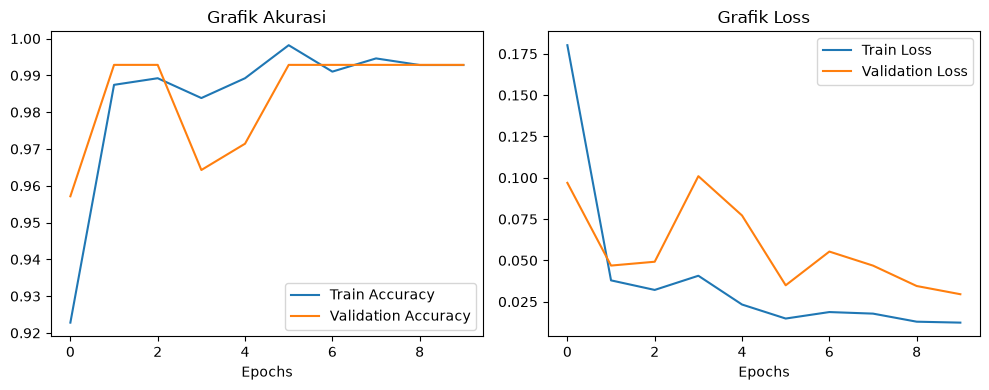


[SUKSES] Model berhasil disimpan sebagai model_xception.h5 di direktori ini.


In [6]:
# Menampilkan grafik Akurasi
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Grafik Akurasi')
plt.xlabel('Epochs')
plt.legend()

# Menampilkan grafik Loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Grafik Loss')
plt.xlabel('Epochs')
plt.legend()
plt.tight_layout()
plt.show()

# Simpan model
MODEL_NAME = "model_xception.h5"
model.save(MODEL_NAME)
print(f"\n[SUKSES] Model berhasil disimpan sebagai {MODEL_NAME} di direktori ini.")

In [7]:
plt.savefig('static/training_graph.png', bbox_inches='tight')


<Figure size 640x480 with 0 Axes>

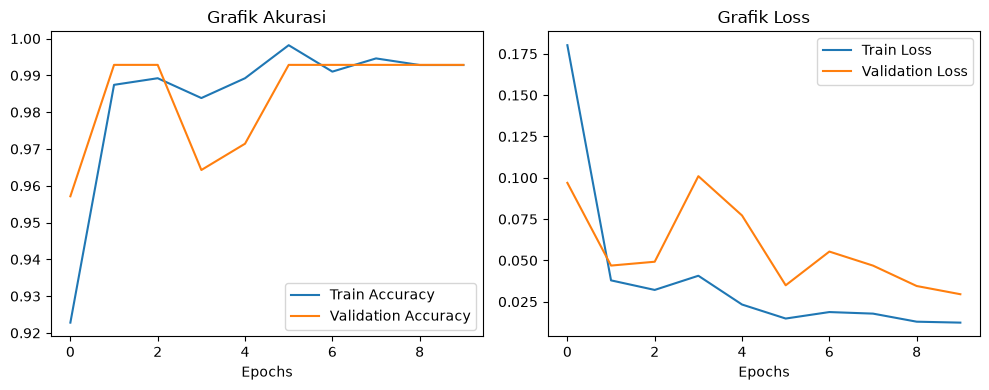

Grafik berhasil dibuat dan disimpan ke folder static!


In [8]:
import matplotlib.pyplot as plt

# 1. Siapkan kanvas grafik
plt.figure(figsize=(10, 4))

# 2. Gambar grafik Akurasi (pastikan variabel history masih ada di memori)
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Grafik Akurasi')
plt.xlabel('Epochs')
plt.legend()

# 3. Gambar grafik Loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Grafik Loss')
plt.xlabel('Epochs')
plt.legend()
plt.tight_layout()

# 4. SIMPAN GAMBAR DULU (Wajib sebelum plt.show)
# Pastikan folder static sudah ada di direktori yang sama dengan .ipynb ini
plt.savefig('static/training_graph.png', bbox_inches='tight')

# 5. BARU TAMPILKAN GAMBAR
plt.show()

print("Grafik berhasil dibuat dan disimpan ke folder static!")